# Customer Churn Prediction and Segmentation 

# Optimized Machine Learning Notebook

## 1. Project Overview

This notebook is an optimized version of the original CBSOT internship implementation.

The project keeps the same two objectives:

1. Predict telecom customer churn using supervised machine learning.
2. Segment customers using K-Means clustering for business-oriented retention strategies.

Key improvements in this notebook:

- Local dataset loading instead of Google Drive loading.
- Cleaner notebook organization.
- Stratified train-test split.
- Balanced Random Forest and hyperparameter tuning with `RandomizedSearchCV`.
- XGBoost comparison when the package is available.
- Evaluation using Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix, Classification Report, and ROC Curve.
- Improved feature importance visualization.
- K-Means segmentation with Elbow Method and business-friendly segment names.
- CLTV used only after prediction for business analysis, not as a model input feature.

## 2. Import Libraries

In [32]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.width", 100)
pd.set_option("display.max_columns", 12)
pd.set_option("display.max_colwidth", 60)
RANDOM_STATE = 42

## 3. Load Dataset

In [33]:
dataset_candidates = [
    Path("../dataset/Telco_customer_churn.xlsx"),
    Path("dataset/Telco_customer_churn.xlsx"),
    Path("../dataset/telco_customer_churn.xlsx"),
    Path("dataset/telco_customer_churn.xlsx"),
]

dataset_path = next((path for path in dataset_candidates if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("Dataset not found. Please check the dataset folder path.")

df = pd.read_excel(dataset_path)

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70 + "\n")
print(f"Path : {dataset_path}")
print(f"Number of Rows : {df.shape[0]}")
print(f"Number of Cols : {df.shape[1]}\n")

display(df.head())


DATASET SUMMARY

Path : ..\dataset\Telco_customer_churn.xlsx
Number of Rows : 7043
Number of Cols : 33



,CustomerID,Count,Country,State,City,Zip Code,...,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,...,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,...,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,...,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,...,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,...,5036.3,Yes,1,89,5340,Competitor had better devices


## 4. Exploratory Data Analysis

In [34]:
print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70 + "\n")

column_summary = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notna().sum().values,
    "Data Type": df.dtypes.astype(str).values,
})
display(column_summary)

print("\nSummary Statistics")
print("-" * 70)
display(df.describe(include="all").T.round(4))

print("\nChurn Distribution (%)")
print("-" * 70)
display(df["Churn Label"].value_counts(normalize=True).mul(100).round(4).to_frame("Percentage"))


DATASET OVERVIEW



,Column,Non-Null Count,Data Type
0,CustomerID,7043,object
1,Count,7043,int64
2,Country,7043,object
3,State,7043,object
4,City,7043,object
5,Zip Code,7043,int64
6,Lat Long,7043,object
7,Latitude,7043,float64
8,Longitude,7043,float64
9,Gender,7043,object



Summary Statistics
----------------------------------------------------------------------


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"34.159534, -116.425984",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Churn Distribution (%)
----------------------------------------------------------------------


,Percentage
Churn Label,
No,73.463
Yes,26.537


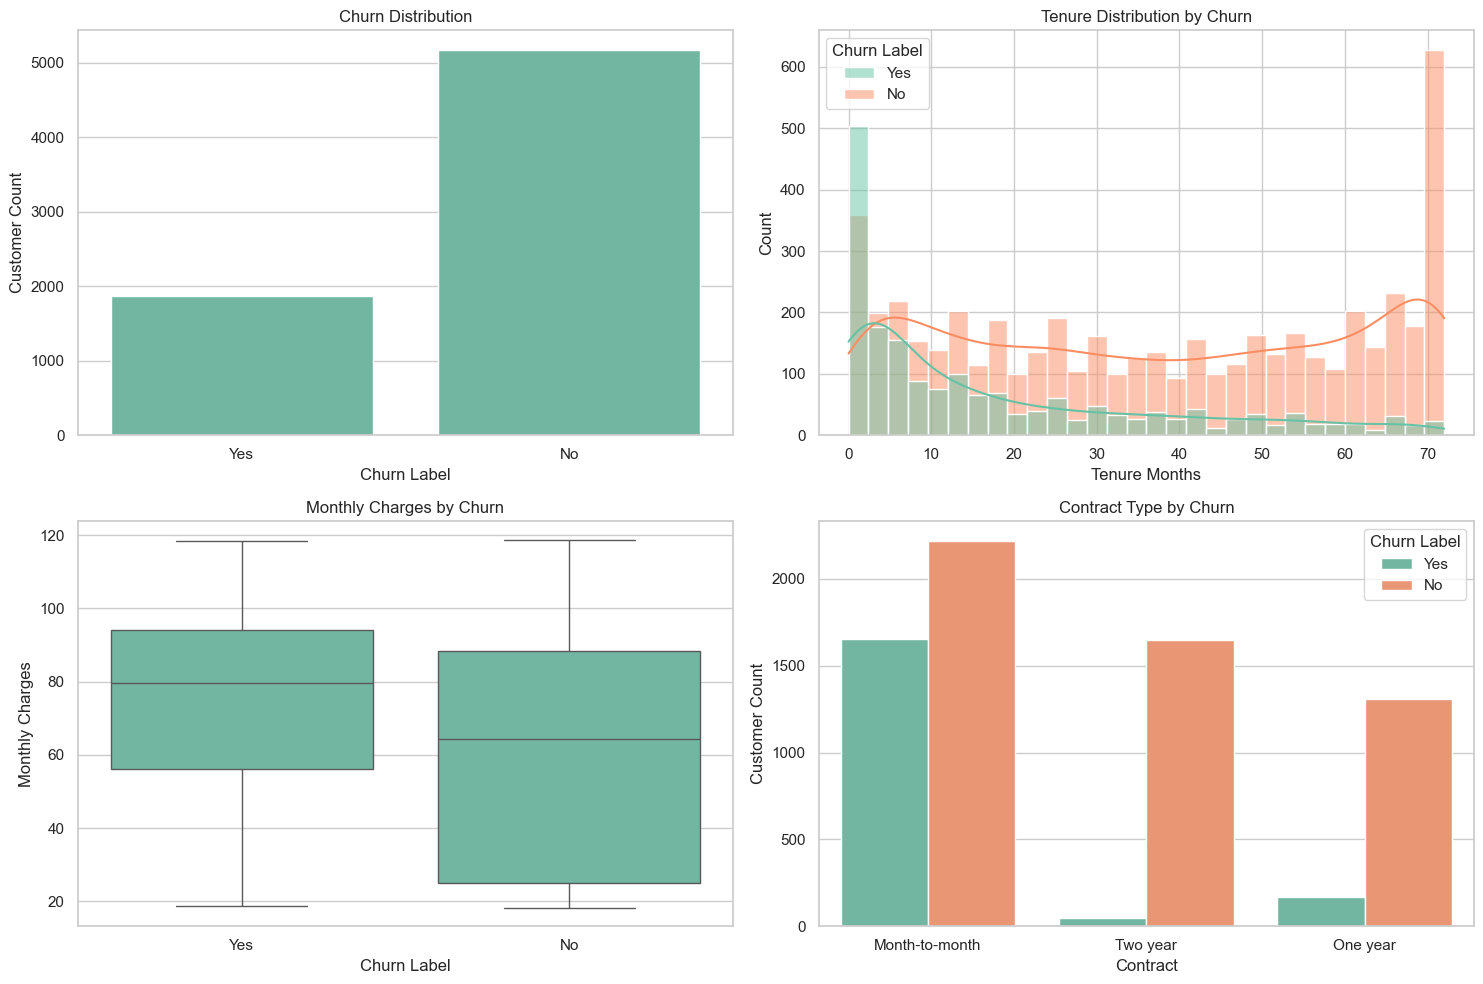

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df, x="Churn Label", ax=axes[0, 0])
axes[0, 0].set_title("Churn Distribution")
axes[0, 0].set_xlabel("Churn Label")
axes[0, 0].set_ylabel("Customer Count")

sns.histplot(data=df, x="Tenure Months", hue="Churn Label", bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Tenure Distribution by Churn")
axes[0, 1].set_xlabel("Tenure Months")

sns.boxplot(data=df, x="Churn Label", y="Monthly Charges", ax=axes[1, 0])
axes[1, 0].set_title("Monthly Charges by Churn")
axes[1, 0].set_xlabel("Churn Label")
axes[1, 0].set_ylabel("Monthly Charges")

sns.countplot(data=df, x="Contract", hue="Churn Label", ax=axes[1, 1])
axes[1, 1].set_title("Contract Type by Churn")
axes[1, 1].set_xlabel("Contract")
axes[1, 1].set_ylabel("Customer Count")

plt.tight_layout()
plt.show()

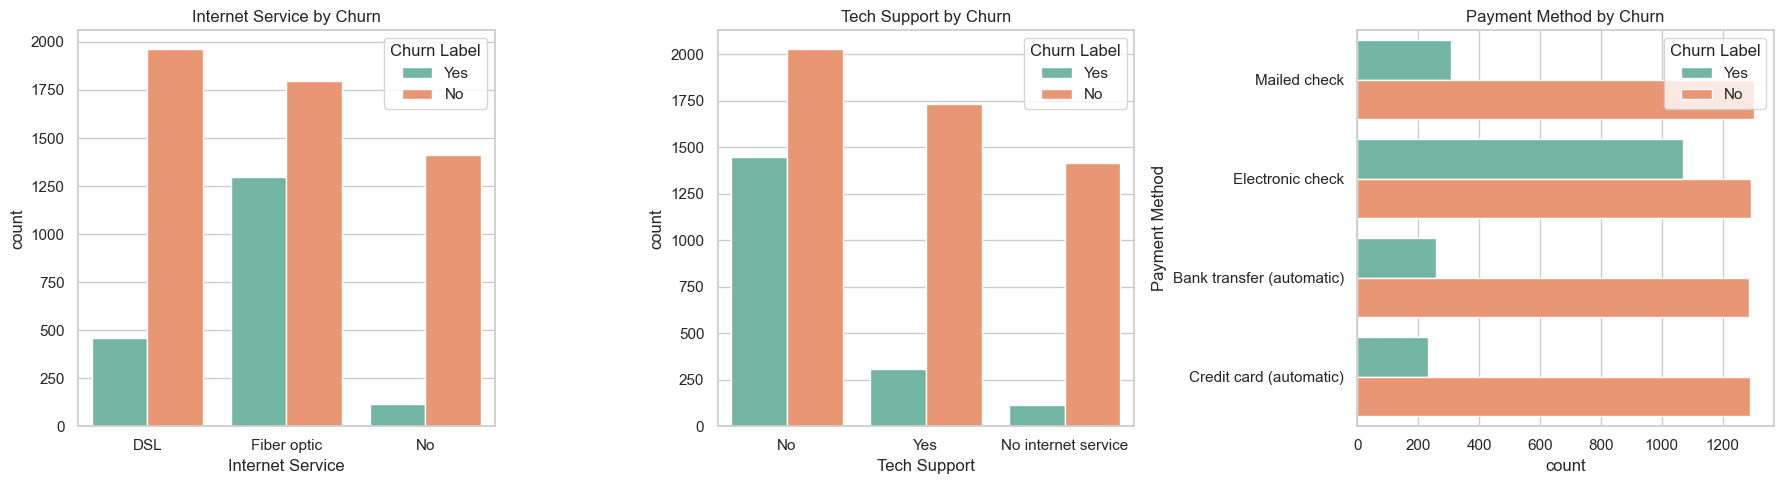

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="Internet Service", hue="Churn Label", ax=axes[0])
axes[0].set_title("Internet Service by Churn")

sns.countplot(data=df, x="Tech Support", hue="Churn Label", ax=axes[1])
axes[1].set_title("Tech Support by Churn")

sns.countplot(data=df, y="Payment Method", hue="Churn Label", ax=axes[2])
axes[2].set_title("Payment Method by Churn")

plt.tight_layout()
plt.show()

## 5. Data Cleaning

In [36]:
data = df.copy()

# The original internship notebook converted Total Charges to numeric and filled new-customer blanks with 0.
data["Total Charges"] = pd.to_numeric(data["Total Charges"], errors="coerce")
missing_total_charges = data["Total Charges"].isna().sum()
data["Total Charges"] = data["Total Charges"].fillna(0)

print("\n" + "=" * 70)
print("DATA CLEANING SUMMARY")
print("=" * 70 + "\n")
print("Converted 'Total Charges' to numeric.")
print(f"Missing Total Charges filled : {missing_total_charges}")
print(f"Duplicate rows found         : {data.duplicated().sum()}\n")


DATA CLEANING SUMMARY

Converted 'Total Charges' to numeric.
Missing Total Charges filled : 11
Duplicate rows found         : 0



## 6. Feature Engineering

In [23]:
business_columns = [
    "CustomerID",
    "CLTV",
    "Churn Label",
    "Churn Reason",
]
business_data = data[[col for col in business_columns if col in data.columns]].copy()

drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Reason",
    "Churn Score",
    "CLTV",
]

model_data = data.drop(columns=[col for col in drop_columns if col in data.columns])

X = model_data.drop(columns=["Churn Value"])
y = model_data["Churn Value"]
X_encoded = pd.get_dummies(X, drop_first=True)

print("\n" + "=" * 70)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 70 + "\n")
print(f"Encoded feature rows : {X_encoded.shape[0]}")
print(f"Encoded feature cols : {X_encoded.shape[1]}\n")

print("Target Distribution (%)")
print("-" * 70)
display(y.value_counts(normalize=True).mul(100).round(4).to_frame("Percentage"))


FEATURE ENGINEERING SUMMARY

Encoded feature rows : 7043
Encoded feature cols : 30

Target Distribution (%)
----------------------------------------------------------------------


,Percentage
Churn Value,
0,73.463
1,26.537


## 7. Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("\n" + "=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70 + "\n")
print(f"Training rows : {X_train.shape[0]}")
print(f"Training cols : {X_train.shape[1]}")
print(f"Testing rows  : {X_test.shape[0]}")
print(f"Testing cols  : {X_test.shape[1]}\n")

print("Training Target Distribution (%)")
print("-" * 70)
display(y_train.value_counts(normalize=True).mul(100).round(4).to_frame("Percentage"))


TRAIN-TEST SPLIT

Training rows : 5634
Training cols : 30
Testing rows  : 1409
Testing cols  : 30

Training Target Distribution (%)
----------------------------------------------------------------------


,Percentage
Churn Value,
0,73.4647
1,26.5353


## 8. Baseline Random Forest

In [9]:
def evaluate_model(model_name, model, X_test, y_test):
    """Return test-set classification metrics for a fitted model."""
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        roc_auc = np.nan

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc,
        "Predictions": y_pred,
        "Probabilities": y_prob,
        "Estimator": model,
    }


baseline_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
)
baseline_rf.fit(X_train, y_train)

baseline_results = evaluate_model("Baseline Random Forest", baseline_rf, X_test, y_test)
print("\n" + "=" * 70)
print("BASELINE RANDOM FOREST RESULTS")
print("=" * 70 + "\n")

baseline_table = pd.DataFrame([
    {k: v for k, v in baseline_results.items()
     if k not in ["Predictions", "Probabilities", "Estimator"]}
]).round(4)
display(baseline_table)


BASELINE RANDOM FOREST RESULTS



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline Random Forest,0.7928,0.6314,0.5267,0.5743,0.8327


## 9. Optimized Random Forest

In [10]:
scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

rf_param_grid = {
    "n_estimators": [100, 150, 200, 300, 400, 500, 700],
    "max_depth": [4, 6, 8, 10, 12, 15, 20, 25, 30, None],
    "min_samples_split": [2, 4, 5, 8, 10, 15, 20],
    "min_samples_leaf": [1, 2, 3, 4, 5, 8, 10],
    "max_features": ["sqrt", "log2", 0.4, 0.6, 0.8, None],
    "class_weight": [None, "balanced", "balanced_subsample"],
    "bootstrap": [True, False],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_distributions=rf_param_grid,
    n_iter=60,
    scoring=scoring_metrics,
    refit="accuracy",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)
optimized_rf = rf_search.best_estimator_

print("\n" + "=" * 70)
print("TUNED RANDOM FOREST")
print("=" * 70 + "\n")
print("Best parameters selected by cross-validated Accuracy:")
display(pd.DataFrame([rf_search.best_params_]))

print("Cross-Validation Scores")
print("-" * 70)
print(f"Accuracy : {rf_search.cv_results_['mean_test_accuracy'][rf_search.best_index_]:.4f}")
print(f"Recall   : {rf_search.cv_results_['mean_test_recall'][rf_search.best_index_]:.4f}\n")

optimized_rf_results = evaluate_model("Tuned Random Forest", optimized_rf, X_test, y_test)
optimized_rf_results["Best CV Accuracy"] = rf_search.cv_results_["mean_test_accuracy"][rf_search.best_index_]
optimized_rf_results["Best CV Recall"] = rf_search.cv_results_["mean_test_recall"][rf_search.best_index_]
optimized_rf_table = pd.DataFrame([
    {k: v for k, v in optimized_rf_results.items()
     if k not in ["Predictions", "Probabilities", "Estimator"]}
]).round(4)
display(optimized_rf_table)

Fitting 5 folds for each of 60 candidates, totalling 300 fits

TUNED RANDOM FOREST

Best parameters selected by cross-validated Accuracy:


,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,class_weight,bootstrap
0,150,20,10,sqrt,15,None,True


Cross-Validation Scores
----------------------------------------------------------------------
Accuracy : 0.8083
Recall   : 0.5124



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Best CV Accuracy,Best CV Recall
0,Tuned Random Forest,0.8077,0.6782,0.5241,0.5913,0.8544,0.8083,0.5124


## 10. XGBoost Model

In [11]:
xgb_results = None
xgb_model = None

try:
    from xgboost import XGBClassifier

    negative_count = (y_train == 0).sum()
    positive_count = (y_train == 1).sum()
    imbalance_ratio = negative_count / positive_count

    xgb_param_grid = {
        "n_estimators": [100, 150, 200, 300, 400, 600],
        "max_depth": [2, 3, 4, 5, 6, 8],
        "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1, 0.15],
        "subsample": [0.65, 0.75, 0.85, 0.95, 1.0],
        "colsample_bytree": [0.65, 0.75, 0.85, 0.95, 1.0],
        "min_child_weight": [1, 2, 3, 5, 7, 10],
        "gamma": [0, 0.05, 0.1, 0.2, 0.5, 1.0],
        "reg_alpha": [0, 0.01, 0.05, 0.1, 0.5],
        "reg_lambda": [0.5, 1.0, 1.5, 2.0, 3.0],
        "scale_pos_weight": [1, np.sqrt(imbalance_ratio), imbalance_ratio],
    }

    xgb_search = RandomizedSearchCV(
        estimator=XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        param_distributions=xgb_param_grid,
        n_iter=50,
        scoring=scoring_metrics,
        refit="accuracy",
        cv=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )

    xgb_search.fit(X_train, y_train)
    xgb_model = xgb_search.best_estimator_
    print("\n" + "=" * 70)
    print("XGBOOST MODEL")
    print("=" * 70 + "\n")
    print("Best parameters selected by cross-validated Accuracy:")
    display(pd.DataFrame([xgb_search.best_params_]))

    print("Cross-Validation Scores")
    print("-" * 70)
    print(f"Accuracy : {xgb_search.cv_results_['mean_test_accuracy'][xgb_search.best_index_]:.4f}")
    print(f"Recall   : {xgb_search.cv_results_['mean_test_recall'][xgb_search.best_index_]:.4f}\n")

    xgb_results = evaluate_model("XGBoost", xgb_model, X_test, y_test)
    xgb_results["Best CV Accuracy"] = xgb_search.cv_results_["mean_test_accuracy"][xgb_search.best_index_]
    xgb_results["Best CV Recall"] = xgb_search.cv_results_["mean_test_recall"][xgb_search.best_index_]
    xgb_table = pd.DataFrame([
        {k: v for k, v in xgb_results.items()
         if k not in ["Predictions", "Probabilities", "Estimator"]}
    ]).round(4)
    display(xgb_table)

except ImportError:
    print("\n" + "=" * 70)
    print("XGBOOST MODEL")
    print("=" * 70 + "\n")
    print("XGBoost is not installed in this environment.")
    print("Random Forest will remain the final model candidate.\n")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

XGBOOST MODEL

Best parameters selected by cross-validated Accuracy:


,subsample,scale_pos_weight,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree
0,0.85,1,1.0,0,200,10,2,0.07,0,1.0


Cross-Validation Scores
----------------------------------------------------------------------
Accuracy : 0.8115
Recall   : 0.5605



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Best CV Accuracy,Best CV Recall
0,XGBoost,0.8062,0.6656,0.5428,0.5979,0.8565,0.8115,0.5605


## 11. Model Comparison

In [12]:
all_results = [baseline_results, optimized_rf_results]
if xgb_results is not None:
    all_results.append(xgb_results)

excluded_columns = ["Predictions", "Probabilities", "Estimator"]
comparison_table = pd.DataFrame([
    {k: v for k, v in result.items() if k not in excluded_columns}
    for result in all_results
])

metric_columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
comparison_display = comparison_table[["Model"] + metric_columns].sort_values(
    by=["Accuracy", "Recall"],
    ascending=False,
)
print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70 + "\n")
display(comparison_display.round(4))

accuracy_tolerance = 0.005
highest_accuracy = max(result["Accuracy"] for result in all_results)
accuracy_tied_results = [
    result for result in all_results
    if highest_accuracy - result["Accuracy"] < accuracy_tolerance
]

best_result = sorted(
    accuracy_tied_results,
    key=lambda result: (result["Recall"], result["Accuracy"], result["ROC-AUC"]),
    reverse=True,
)[0]

final_model_name = best_result["Model"]
final_model = best_result["Estimator"]

selection_summary_lines = [
    "Selected Model",
    "-" * 50,
    f"Model    : {final_model_name}",
    f"Accuracy : {best_result['Accuracy']:.4f}",
    f"Recall   : {best_result['Recall']:.4f}",
    f"ROC-AUC  : {best_result['ROC-AUC']:.4f}",
    "",
    "Reason:",
    "- The model selection rule prefers highest Accuracy.",
    f"- If Accuracy differs by less than {accuracy_tolerance:.1%},",
    "  the model with higher Recall is selected.",
]
selection_summary = "\n".join(selection_summary_lines)

print("\n" + "=" * 70)
print("FINAL MODEL SELECTION")
print("=" * 70 + "\n")
print(selection_summary + "\n")


MODEL COMPARISON



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Tuned Random Forest,0.8077,0.6782,0.5241,0.5913,0.8544
2,XGBoost,0.8062,0.6656,0.5428,0.5979,0.8565
0,Baseline Random Forest,0.7928,0.6314,0.5267,0.5743,0.8327



FINAL MODEL SELECTION

Selected Model
--------------------------------------------------
Model    : XGBoost
Accuracy : 0.8062
Recall   : 0.5428
ROC-AUC  : 0.8565

Reason:
- The model selection rule prefers highest Accuracy.
- If Accuracy differs by less than 0.5%,
  the model with higher Recall is selected.



## 12. Final Evaluation


FINAL EVALUATION

Selected Model
--------------------------------------------------
Model    : XGBoost
Accuracy : 0.8062
Recall   : 0.5428
ROC-AUC  : 0.8565

Reason:
- The model selection rule prefers highest Accuracy.
- If Accuracy differs by less than 0.5%,
  the model with higher Recall is selected.

Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



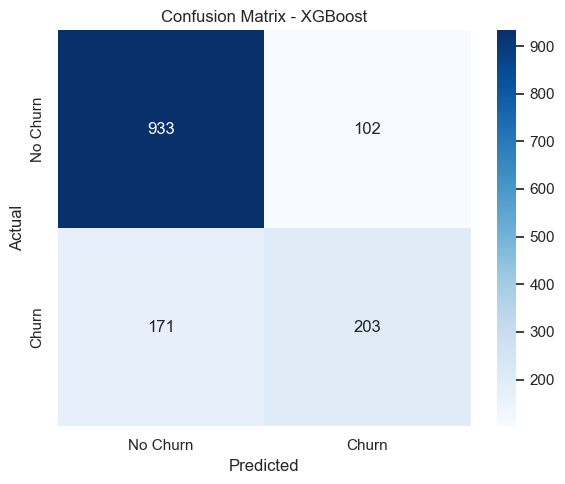

In [13]:
final_predictions = best_result["Predictions"]
final_probabilities = best_result["Probabilities"]

print("\n" + "=" * 70)
print("FINAL EVALUATION")
print("=" * 70 + "\n")
print(selection_summary + "\n")

print("Classification Report")
print("-" * 70)
print(classification_report(y_test, final_predictions))

cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
)
plt.title(f"Confusion Matrix - {final_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

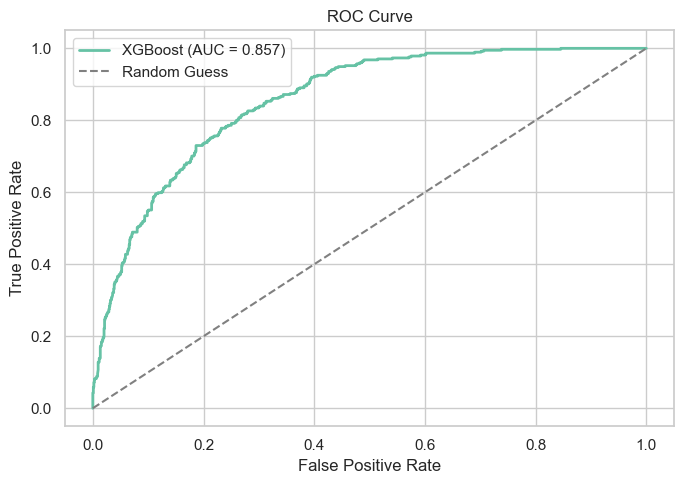

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, final_probabilities)
auc_score = roc_auc_score(y_test, final_probabilities)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"{final_model_name} (AUC = {auc_score:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Feature Importance Analysis

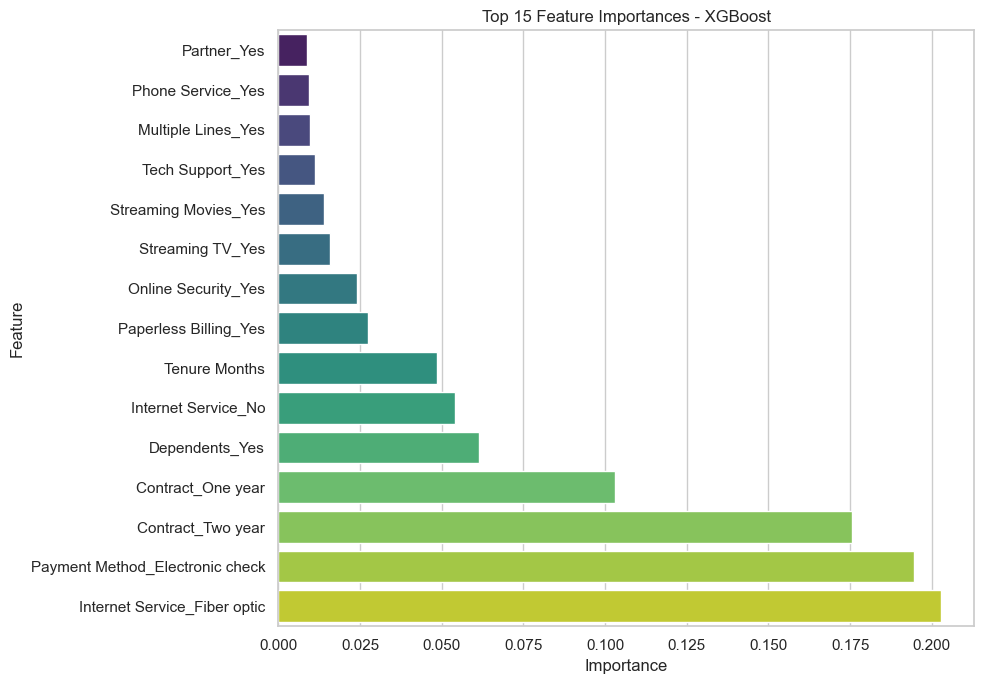


Top 15 Feature Importances
----------------------------------------------------------------------


,Feature,Importance
10,Internet Service_Fiber optic,0.2028
28,Payment Method_Electronic check,0.1945
25,Contract_Two year,0.1757
24,Contract_One year,0.1029
6,Dependents_Yes,0.0614
11,Internet Service_No,0.0541
0,Tenure Months,0.0485
26,Paperless Billing_Yes,0.0273
13,Online Security_Yes,0.0241
21,Streaming TV_Yes,0.0157


In [15]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": final_model.feature_importances_,
}).sort_values("Importance", ascending=False)

top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
sns.barplot(data=top_features, x="Importance", y="Feature", palette="viridis")
plt.title(f"Top 15 Feature Importances - {final_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("\nTop 15 Feature Importances")
print("-" * 70)
display(feature_importance.head(15).round(4))

## 14. Customer Segmentation

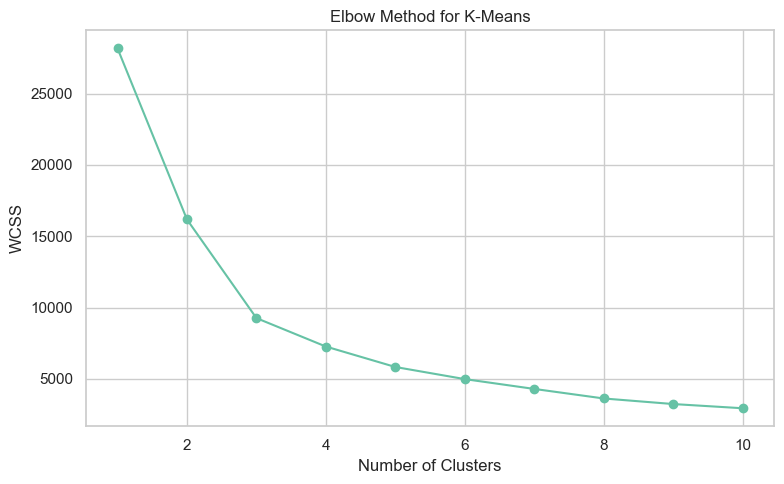

In [16]:
all_churn_probabilities = final_model.predict_proba(X_encoded)[:, 1]

segmentation_data = pd.DataFrame({
    "Tenure Months": data["Tenure Months"],
    "Monthly Charges": data["Monthly Charges"],
    "Total Charges": data["Total Charges"],
    "Churn Probability": all_churn_probabilities,
})

scaler = StandardScaler()
scaled_segmentation_data = scaler.fit_transform(segmentation_data)

wcss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(scaled_segmentation_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.tight_layout()
plt.show()

In [17]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
segmentation_data["Cluster"] = kmeans.fit_predict(scaled_segmentation_data)

# CLTV is added only after clustering for business interpretation, not model training or cluster fitting.
if "CLTV" in data.columns:
    segmentation_data["CLTV"] = data["CLTV"]

cluster_profile = segmentation_data.groupby("Cluster").mean().round(2)
print("\n" + "=" * 70)
print("CLUSTER PROFILE")
print("=" * 70 + "\n")
display(cluster_profile.round(4))

def create_segment_names(profile):
    """Map cluster IDs to business names using cluster behavior."""
    names = {}
    high_risk_cluster = profile["Churn Probability"].idxmax()
    names[high_risk_cluster] = "High Risk New Customers"

    remaining_clusters = [cluster for cluster in profile.index if cluster != high_risk_cluster]
    premium_cluster = profile.loc[remaining_clusters, "Monthly Charges"].idxmax()
    names[premium_cluster] = "Loyal Premium Customers"

    for cluster in remaining_clusters:
        if cluster not in names:
            names[cluster] = "Budget Loyal Customers"

    return names


segment_names = create_segment_names(cluster_profile)
segmentation_data["Customer Segment"] = segmentation_data["Cluster"].map(segment_names)

segment_summary = segmentation_data.groupby("Customer Segment").agg(
    Customers=("Cluster", "count"),
    Avg_Tenure_Months=("Tenure Months", "mean"),
    Avg_Monthly_Charges=("Monthly Charges", "mean"),
    Avg_Total_Charges=("Total Charges", "mean"),
    Avg_Churn_Probability=("Churn Probability", "mean"),
)

if "CLTV" in segmentation_data.columns:
    segment_summary["Avg_CLTV"] = segmentation_data.groupby("Customer Segment")["CLTV"].mean()

segment_summary = segment_summary.round(2).sort_values("Avg_Churn_Probability", ascending=False)
print("\nSegment Summary")
print("-" * 70)
display(segment_summary.round(4))


CLUSTER PROFILE



,Tenure Months,Monthly Charges,Total Charges,Churn Probability,CLTV
Cluster,,,,,
0,28.59,34.92,967.06,0.11,4275.99
1,58.18,89.90,5228.03,0.15,4928.72
2,10.76,76.46,913.08,0.59,4016.43



Segment Summary
----------------------------------------------------------------------


,Customers,Avg_Tenure_Months,Avg_Monthly_Charges,Avg_Total_Charges,Avg_Churn_Probability,Avg_CLTV
Customer Segment,,,,,,
High Risk New Customers,2152,10.76,76.46,913.08,0.59,4016.43
Loyal Premium Customers,2197,58.18,89.90,5228.03,0.15,4928.72
Budget Loyal Customers,2694,28.59,34.92,967.06,0.11,4275.99


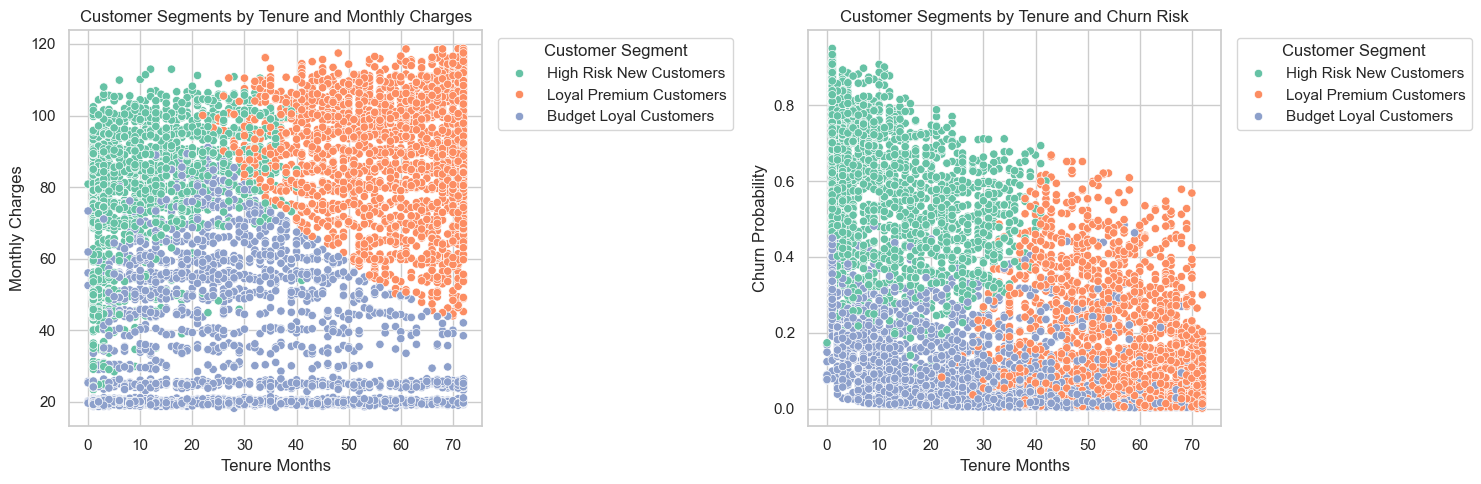

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=segmentation_data,
    x="Tenure Months",
    y="Monthly Charges",
    hue="Customer Segment",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Customer Segments by Tenure and Monthly Charges")

sns.scatterplot(
    data=segmentation_data,
    x="Tenure Months",
    y="Churn Probability",
    hue="Customer Segment",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Customer Segments by Tenure and Churn Risk")

for ax in axes:
    ax.legend(title="Customer Segment", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 15. Business Insights

In [19]:
business_output = business_data.copy()
business_output["Predicted Churn Probability"] = all_churn_probabilities
business_output["Customer Segment"] = segmentation_data["Customer Segment"]

if "CLTV" in business_output.columns:
    high_value_at_risk = business_output[
        (business_output["Predicted Churn Probability"] >= business_output["Predicted Churn Probability"].quantile(0.75))
        & (business_output["CLTV"] >= business_output["CLTV"].quantile(0.75))
    ].sort_values(["Predicted Churn Probability", "CLTV"], ascending=False)

    print("\n" + "=" * 70)
    print("HIGH VALUE CUSTOMERS AT RISK")
    print("=" * 70 + "\n")
    print(f"Customer count : {len(high_value_at_risk)}\n")
    display(high_value_at_risk.head(10).round(4))

retention_strategy = pd.DataFrame({
    "Customer Segment": [
        "High Risk New Customers",
        "Budget Loyal Customers",
        "Loyal Premium Customers",
    ],
    "Business Interpretation": [
        "Customers with higher churn probability and shorter relationship history.",
        "Price-sensitive customers with relatively stable behavior.",
        "Longer-tenure or higher-spend customers who are valuable to retain and grow.",
    ],
    "Recommended Action": [
        "Prioritize onboarding support, proactive service calls, and early retention offers.",
        "Use loyalty rewards, value-focused bundles, and affordable add-ons.",
        "Provide premium support, personalized upgrades, and relationship-based retention offers.",
    ],
})

print("\nRetention Strategy by Segment")
print("-" * 70)
display(retention_strategy)


HIGH VALUE CUSTOMERS AT RISK

Customer count : 287



,CustomerID,CLTV,Churn Label,Churn Reason,Predicted Churn Probability,Customer Segment
886,5178-LMXOP,5795,Yes,Price too high,0.9277,High Risk New Customers
515,9497-QCMMS,5536,Yes,Competitor made better offer,0.9151,High Risk New Customers
1818,0295-PPHDO,5962,Yes,Attitude of support person,0.9082,High Risk New Customers
692,2725-KXXWT,5460,Yes,Lack of self-service on Website,0.9016,High Risk New Customers
1166,3178-FESZO,5797,Yes,Don't know,0.8979,High Risk New Customers
974,6688-UZPWD,5750,Yes,Competitor offered more data,0.8878,High Risk New Customers
738,4102-OQUPX,5429,Yes,Competitor made better offer,0.8804,High Risk New Customers
136,9282-IZGQK,5679,Yes,Don't know,0.8800,High Risk New Customers
213,3027-ZTDHO,5951,Yes,Don't know,0.8772,High Risk New Customers
263,4822-RVYBB,5906,Yes,Competitor offered higher download speeds,0.8737,High Risk New Customers



Retention Strategy by Segment
----------------------------------------------------------------------


,Customer Segment,Business Interpretation,Recommended Action
0,High Risk New Customers,Customers with higher churn probability and shorter rela...,"Prioritize onboarding support, proactive service calls, ..."
1,Budget Loyal Customers,Price-sensitive customers with relatively stable behavior.,"Use loyalty rewards, value-focused bundles, and affordab..."
2,Loyal Premium Customers,Longer-tenure or higher-spend customers who are valuable...,"Provide premium support, personalized upgrades, and rela..."


## 16. Conclusion

This optimized notebook preserves the original internship workflow while improving its presentation and machine learning practice.

The baseline Random Forest remains part of the workflow, and the optimized model is selected by comparing recall, accuracy, and ROC-AUC. Customer segmentation is still based on K-Means, but now includes the Elbow Method, churn probability, business-oriented naming, and retention recommendations.

CLTV is intentionally excluded from model training to avoid leakage, but it is used after prediction for business prioritization. This keeps the model evaluation fair while making the final insights more useful for retention strategy.